## Phase 5 : Feature analysis and selection 

### Objective 
#### Feature engineering produced multiple statistical feature. However, Every feature not contributes equally to electrivcity theft detection. So this notebook evaluates feature quality, identify redundant features, and select the most informative features before machine learning model development.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%store -r consumer_feature

In [3]:
consumer_feature['PAR']=(
    consumer_feature['max_cons']/consumer_feature['mean_cons'].replace(0,np.nan)
)
consumer_feature['PAR'].fillna(0,inplace=True)

C:\Users\vinee\AppData\Local\Temp\ipykernel_12188\1555384415.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  consumer_feature['PAR'].fillna(0,inplace=True)


In [4]:
select_feature = [
    'mean_cons', 'median_cons', 'std_cons','longest_missing_streak', 'zero_ratio',
    'high_cons_ratio', 'PAR', 'cv', 'Stability', 'MMG', 'missing_ratio',
    'spike_count', 'spike_ratio', 'longest_zero_streak'
]
feature_df=consumer_feature[select_feature+['FLAG']]
feature_df=feature_df.fillna(0)
feature_df.head(4)

,mean_cons,median_cons,std_cons,longest_missing_streak,zero_ratio,high_cons_ratio,PAR,cv,Stability,MMG,missing_ratio,spike_count,spike_ratio,longest_zero_streak,FLAG
0,0.947796,0.000,3.101514,2,0.836893,0.105825,19.297399,1.592320,0.385755,0.947796,0.003868,47,0.045631,374,1
1,4.606312,0.955,7.107997,158,0.059102,0.314421,9.675853,1.267856,0.440945,3.651312,0.181818,9,0.010638,50,1
2,8.312549,5.070,10.289867,28,0.047619,0.382353,9.589116,1.104946,0.475072,3.242549,0.309478,20,0.028011,12,1
3,3.638446,0.000,7.999479,6,0.783677,0.216323,11.263049,1.724603,0.367026,3.638446,0.016441,39,0.038348,372,1


In [5]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_cons,42372.0,9.943020,82.032492,0.000000,1.980933,5.708450,10.253886,13601.100000
median_cons,42372.0,8.669256,86.578908,0.000000,1.000000,4.780000,9.031250,14880.000000
std_cons,42372.0,9.858840,254.292799,0.000000,1.481244,3.279685,5.779500,27954.247106
longest_missing_streak,42372.0,244.583003,296.187026,1.000000,4.000000,84.000000,535.250000,1034.000000
zero_ratio,42372.0,0.179510,0.319867,0.000000,0.000000,0.006944,0.168945,1.000000
high_cons_ratio,42372.0,0.356338,0.149869,0.000000,0.306719,0.392912,0.450658,0.973913
PAR,42372.0,20.862290,88.457622,0.000000,2.614051,3.650614,6.297518,1033.000000
cv,42372.0,0.621301,1.225096,0.000000,0.298900,0.444721,0.672571,31.412916
Stability,42372.0,0.685358,0.156388,0.000000,0.597845,0.692139,0.769782,1.000000
MMG,42372.0,1.273764,12.861625,-1278.900000,0.082266,0.530819,1.385900,977.006960


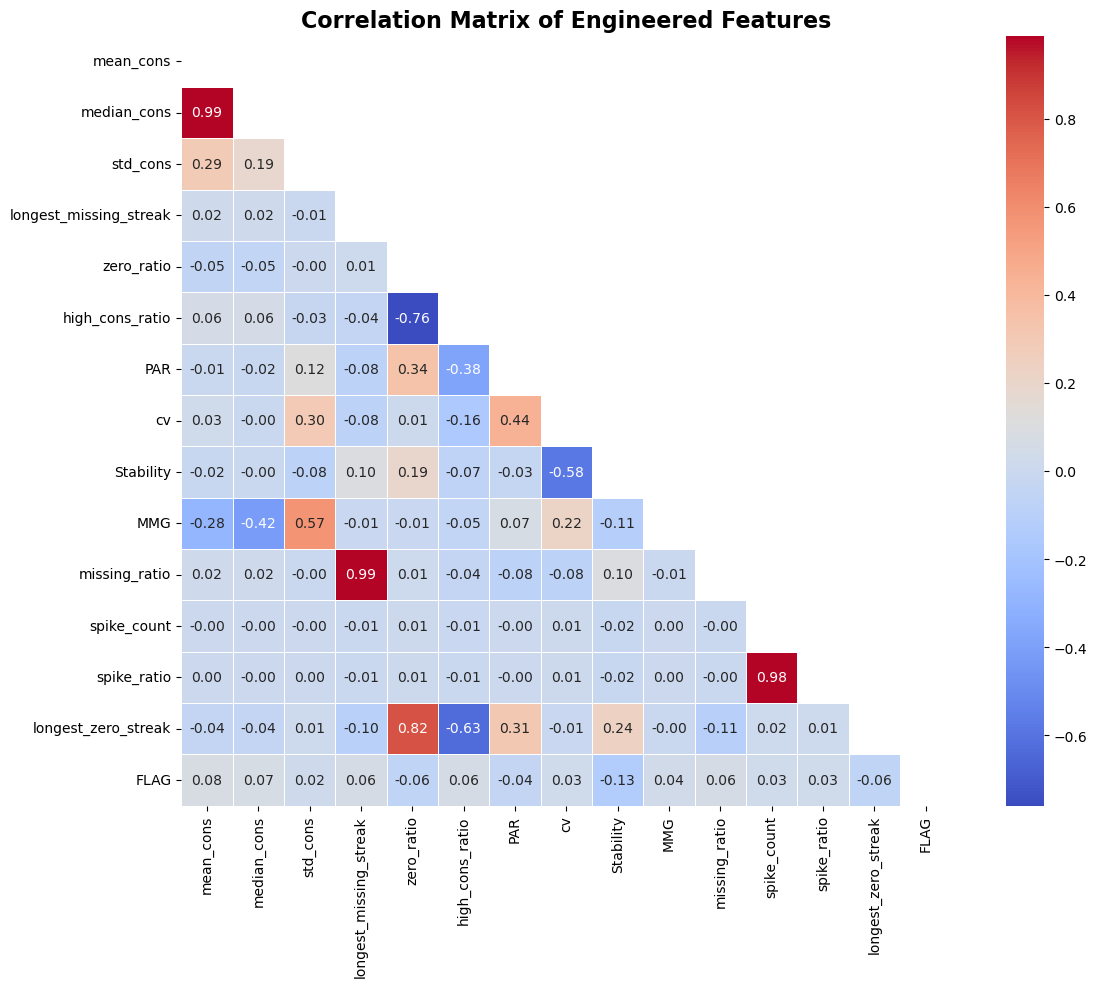

In [6]:
plt.figure(figsize=(14,10))

corr = feature_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=.5,
    square=True
)

plt.title(
    "Correlation Matrix of Engineered Features",
    fontsize=16,
    fontweight="bold"
)

plt.show()

#### Correlation Analysis Summary

- Mean Consumption and Median Consumption exhibit extremely high positive correlation (0.99), indicating redundant information.

- Spike Count and Spike Ratio are also highly correlated (0.98), as Spike Ratio is derived from Spike Count.

- Zero Ratio and Longest Zero Streak show strong positive correlation (0.82), but capture different behavioural aspects.

- PAR demonstrates relatively low correlation with other engineered features, suggesting that it provides unique information.

- Correlation with the target variable (FLAG) is generally weak, indicating that electricity theft detection is a non-linear classification problem where advanced machine learning models are expected to outperform linear approaches.

### Phase 5.2 : Mutual Information analysis
#### Correlation only captures linear relationships between features and the target value but mututal Information measures how much informationn a feature provides about the target variable.

In [7]:
from sklearn.feature_selection import mutual_info_classif
x = feature_df.drop(columns=['FLAG'])
y = feature_df['FLAG']

In [8]:
mi_score = mutual_info_classif(
    x,y,random_state=42
)

In [9]:
mi_df = (
    pd.DataFrame(
        {'Feature':x.columns,
        'MI Score':mi_score}
    )
)
mi_df.sort_values(by='MI Score',ascending=False).reset_index(drop=True)
# MI Score increase -> infomation increase 

,Feature,MI Score
0,longest_missing_streak,0.037969
1,std_cons,0.024048
2,MMG,0.021371
3,missing_ratio,0.017358
4,mean_cons,0.016104
5,Stability,0.014547
6,cv,0.014050
7,median_cons,0.013134
8,zero_ratio,0.009512
9,high_cons_ratio,0.006834


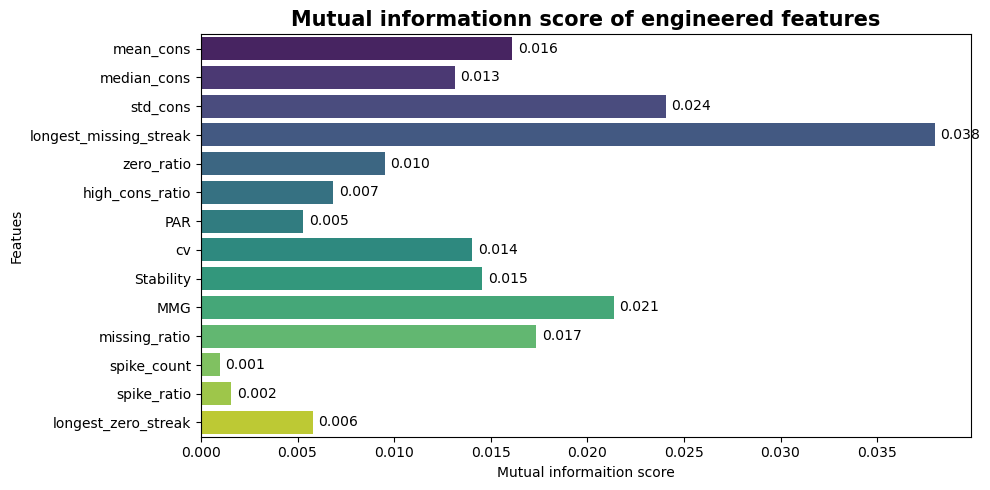

In [10]:
# visualization 1 : Bar plot for MI score
plt.figure(figsize=(10,5))
sns.barplot(
    data=mi_df,x='MI Score',y='Feature',
    hue='Feature',legend=False,palette='viridis'
)
plt.xlabel("Mutual informaition score")
plt.ylabel("Featues")
plt.title("Mutual informationn score of engineered features",fontsize=15,fontweight='bold')
for i, value in enumerate(mi_df["MI Score"]):
    plt.text(
        value + 0.0003,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )
plt.tight_layout()
plt.show()


#### Observation 
- Longest Missing Streak has the **hightest** MI score.
- SD and mean-median-gap also ranked among the most informative feature, suggesting that variability and distribution irregularity play and important role.
- mean consumption, missing ratio and CV contribute useful prediction information 
- Spike count, spike ratio and longest zero streak show **lowest** MI Score
#### conclusion
- MI confirma that behavioural features provide stronger predictive information than other.

### Phase 5.3 : Random forest Feature importance
#### Random forest estimate the feature importance by measuring how much each feature contributes to reducing impurity while contructing decision tree.

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(x,y)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
rf_importance = pd.DataFrame({
    'Feature':x.columns,
    'Importance':rf.feature_importances_
})
rf_importance=(
    rf_importance.sort_values('Importance',ascending=False).
    reset_index(drop=True)
)

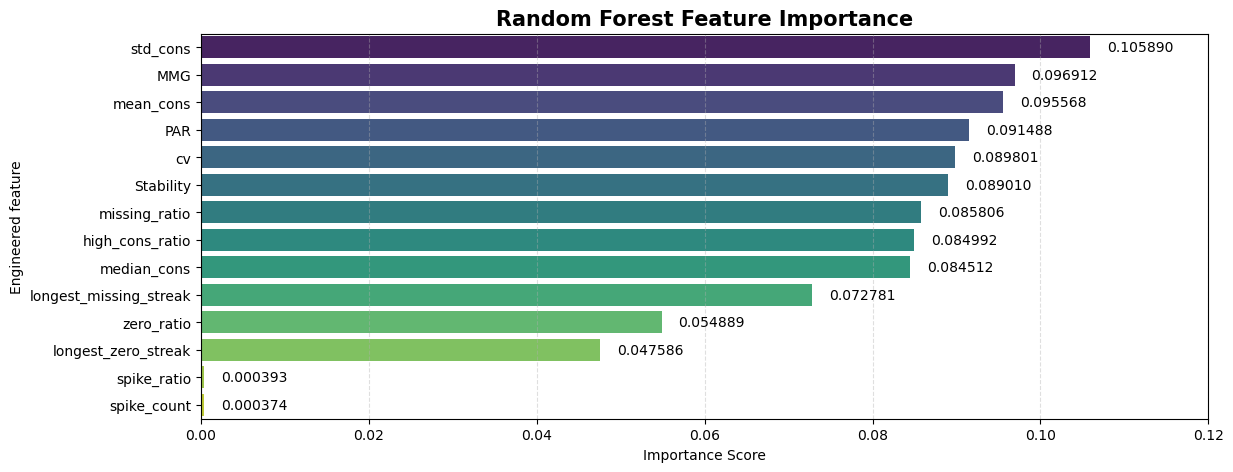

In [13]:
plt.figure(figsize=(13,5))
bars = sns.barplot(
    data=rf_importance,x='Importance',y='Feature',
    hue='Feature',palette='viridis',legend=False
)
for i, value in enumerate(rf_importance['Importance']):
    plt.text(
        value + 0.002,i,f'{value:3f}',va='center',fontsize=10
    )
plt.title("Random Forest Feature Importance",fontsize=15,fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Engineered feature")
plt.xlim(0,0.12)
plt.grid(axis='x',alpha = 0.4,linestyle='--')
#plt.tight_layout()
plt.show()

In [14]:
print("Top 10 Most Important Features\n")
display(rf_importance.head(10))

Top 10 Most Important Features



,Feature,Importance
0,std_cons,0.105890
1,MMG,0.096912
2,mean_cons,0.095568
3,PAR,0.091488
4,cv,0.089801
5,Stability,0.089010
6,missing_ratio,0.085806
7,high_cons_ratio,0.084992
8,median_cons,0.084512
9,longest_missing_streak,0.072781


#### Key Observatins
- SD emerged as the most influential feature along with that mean median gap , mean consumption and peak to average ratio(PAR) also demostrate strong predictive importance.
- missing ratio and longest missing streak consistently ranked among the most informative behavioural features.
- spike ount and spike ratio contribute no predictive information So they are dropped here 

### Phase 5.4 : Multicollinearity Analysis (VIF)
#### Highly correlated feature often carry similar information that causes redundancy.
#### Variance Inflation Factor (VIF) measures how strongly a feature can be explain by other features

#### General Interpretation 
|VIF|Interpretation|
|---|--------------|
|<5 |No multicollinearity|
|5-10|Moderate|
|>10|High Multicollinearity

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [16]:
x_vif=feature_df.drop(columns=['FLAG']).copy()
x_vif=x_vif.fillna(x_vif.median(numeric_only=True))

In [17]:
vif=pd.DataFrame(
    {
        'Feature':x_vif.columns,
        'VIF':[
            variance_inflation_factor(x_vif.values,i)
            for i in range(x_vif.shape[1])
        ]
    }
)

c:\Users\vinee\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


c:\Users\vinee\anaconda3\Lib\site-packages\matplotlib\transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


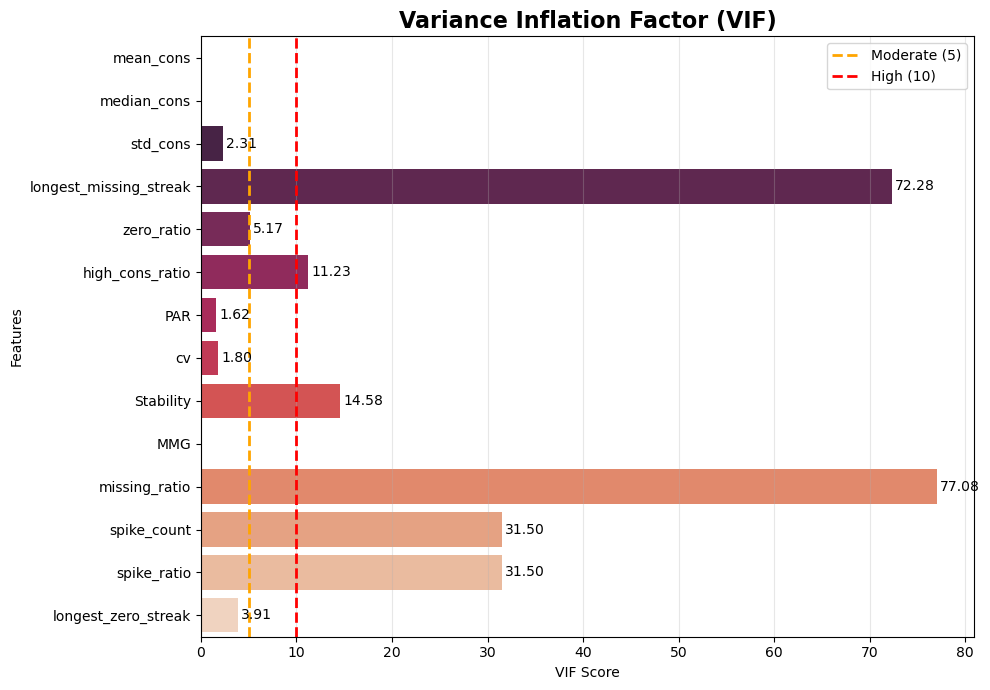

In [18]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=vif,
    x="VIF",
    y="Feature",
    hue="Feature",
    palette="rocket",
    legend=False
)

for i, value in enumerate(vif["VIF"]):
    plt.text(
        value + 0.3,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Moderate (5)"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    linewidth=2,
    label="High (10)"
)

plt.title(
    "Variance Inflation Factor (VIF)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("VIF Score")
plt.ylabel("Features")

plt.legend()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [19]:
def vif_status(x):
    if x<5 :
        return 'Low'
    elif x<10 :
        return 'moderate'
    else :
        return 'High'
vif['Status']=vif['VIF'].apply(vif_status)
display(vif)

,Feature,VIF,Status
0,mean_cons,inf,High
1,median_cons,inf,High
2,std_cons,2.312342,Low
3,longest_missing_streak,72.281307,High
4,zero_ratio,5.174559,moderate
5,high_cons_ratio,11.226485,High
6,PAR,1.615506,Low
7,cv,1.802968,Low
8,Stability,14.580554,High
9,MMG,inf,High


In [20]:
x_vif.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_cons,42372.0,9.943020,82.032492,0.000000,1.980933,5.708450,10.253886,13601.100000
median_cons,42372.0,8.669256,86.578908,0.000000,1.000000,4.780000,9.031250,14880.000000
std_cons,42372.0,9.858840,254.292799,0.000000,1.481244,3.279685,5.779500,27954.247106
longest_missing_streak,42372.0,244.583003,296.187026,1.000000,4.000000,84.000000,535.250000,1034.000000
zero_ratio,42372.0,0.179510,0.319867,0.000000,0.000000,0.006944,0.168945,1.000000
high_cons_ratio,42372.0,0.356338,0.149869,0.000000,0.306719,0.392912,0.450658,0.973913
PAR,42372.0,20.862290,88.457622,0.000000,2.614051,3.650614,6.297518,1033.000000
cv,42372.0,0.621301,1.225096,0.000000,0.298900,0.444721,0.672571,31.412916
Stability,42372.0,0.685358,0.156388,0.000000,0.597845,0.692139,0.769782,1.000000
MMG,42372.0,1.273764,12.861625,-1278.900000,0.082266,0.530819,1.385900,977.006960


In [21]:
corr = x_vif.corr().abs()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

high_corr.head(20)

mean_cons               median_cons            0.989810
longest_missing_streak  missing_ratio          0.988272
spike_count             spike_ratio            0.983989
zero_ratio              longest_zero_streak    0.818584
                        high_cons_ratio        0.759683
high_cons_ratio         longest_zero_streak    0.632708
cv                      Stability              0.580884
std_cons                MMG                    0.573464
PAR                     cv                     0.437760
median_cons             MMG                    0.418483
high_cons_ratio         PAR                    0.383292
zero_ratio              PAR                    0.344870
PAR                     longest_zero_streak    0.306642
std_cons                cv                     0.297555
mean_cons               std_cons               0.289994
                        MMG                    0.284889
Stability               longest_zero_streak    0.236126
cv                      MMG                    0

In [22]:
x_vif.corr()

,mean_cons,median_cons,std_cons,longest_missing_streak,zero_ratio,high_cons_ratio,PAR,cv,Stability,MMG,missing_ratio,spike_count,spike_ratio,longest_zero_streak
mean_cons,1.000000,0.989810,0.289994,0.020947,-0.051536,0.055347,-0.006239,0.030449,-0.019143,-0.284889,0.021515,-0.000419,0.000050,-0.038761
median_cons,0.989810,1.000000,0.189576,0.021225,-0.046817,0.059185,-0.016277,-0.003931,-0.001257,-0.418483,0.021532,-0.000576,-0.000242,-0.036232
std_cons,0.289994,0.189576,1.000000,-0.005226,-0.001007,-0.025322,0.119181,0.297555,-0.077155,0.573464,-0.004774,-0.000039,0.000104,0.012897
longest_missing_streak,0.020947,0.021225,-0.005226,1.000000,0.013562,-0.040450,-0.081506,-0.077684,0.100461,-0.009273,0.988272,-0.005963,-0.005083,-0.102386
zero_ratio,-0.051536,-0.046817,-0.001007,0.013562,1.000000,-0.759683,0.344870,0.012235,0.193310,-0.013547,0.014772,0.011756,0.010508,0.818584
high_cons_ratio,0.055347,0.059185,-0.025322,-0.040450,-0.759683,1.000000,-0.383292,-0.159424,-0.066281,-0.045397,-0.038368,-0.008544,-0.007938,-0.632708
PAR,-0.006239,-0.016277,0.119181,-0.081506,0.344870,-0.383292,1.000000,0.437760,-0.032142,0.069773,-0.082496,-0.000716,-0.000874,0.306642
cv,0.030449,-0.003931,0.297555,-0.077684,0.012235,-0.159424,0.437760,1.000000,-0.580884,0.220666,-0.076560,0.006443,0.006486,-0.009812
Stability,-0.019143,-0.001257,-0.077155,0.100461,0.193310,-0.066281,-0.032142,-0.580884,1.000000,-0.113635,0.098411,-0.016109,-0.016747,0.236126
MMG,-0.284889,-0.418483,0.573464,-0.009273,-0.013547,-0.045397,0.069773,0.220666,-0.113635,1.000000,-0.007719,0.001203,0.001953,-0.003322


### Features that are kept for further processes

In [53]:
final_feature = [
    
    "std_cons",
    "zero_ratio",
    "high_cons_ratio",
    "PAR",
    "cv",
    'Stability',
    "longest_missing_streak",
    "longest_zero_streak"
]
%store final_feature


Stored 'final_feature' (list)


In [54]:
final_feature

['std_cons',
 'zero_ratio',
 'high_cons_ratio',
 'PAR',
 'cv',
 'Stability',
 'longest_missing_streak',
 'longest_zero_streak']